In [70]:
from typing import List, Dict, Any

from natasha import (
    Segmenter, MorphVocab,
    NewsEmbedding, NewsMorphTagger, NewsSyntaxParser, NewsNERTagger,
    Doc
)
from datasets import load_dataset

from yargy import Parser, rule, or_, not_, and_
from yargy.pipelines import morph_pipeline, caseless_pipeline
from yargy.predicates import gram, normalized, dictionary
from yargy.interpretation import fact
from yargy.tokenizer import MorphTokenizer

from src.parser import process_dataset
from src.utils import load_natasha_data, get_stats
from src.yargy_utils import extract_entities_yargy
from src.eval import evaluate, get_error_pairs
from src.plots import make_simle_stats, plot_ner_word_statistics
from src.error_anal import generate_ner_report, show_top_errors

from src.yargy_rules import FINAL_PER_RULE, PER_ABBREVIATED

import warnings
warnings.filterwarnings("ignore")

In [71]:
dataset = load_dataset("gusevski/factrueval2016", cache_dir='data')
dataset

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})

<Figure size 1600x800 with 0 Axes>

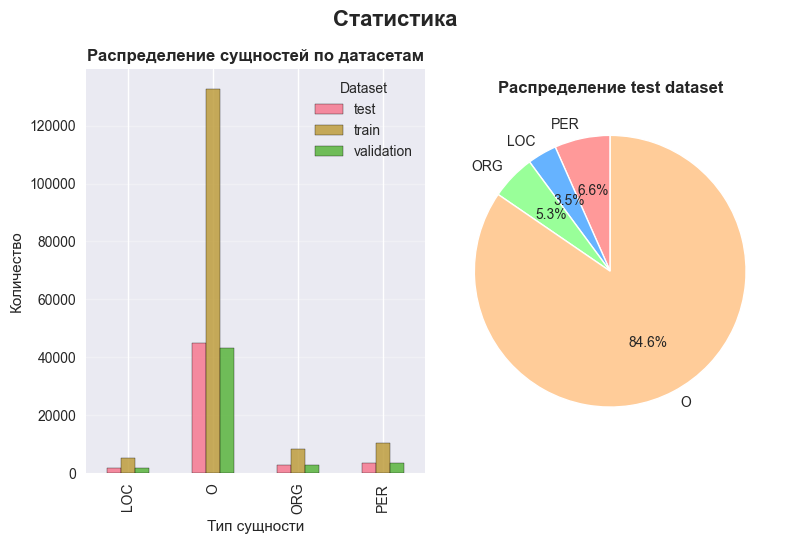

In [72]:
make_simle_stats(get_stats(dataset)) # type: ignore

In [73]:
entity_counts, natasha_data = process_dataset("gusevski/factrueval2016")

Repo card metadata block was not found. Setting CardData to empty.


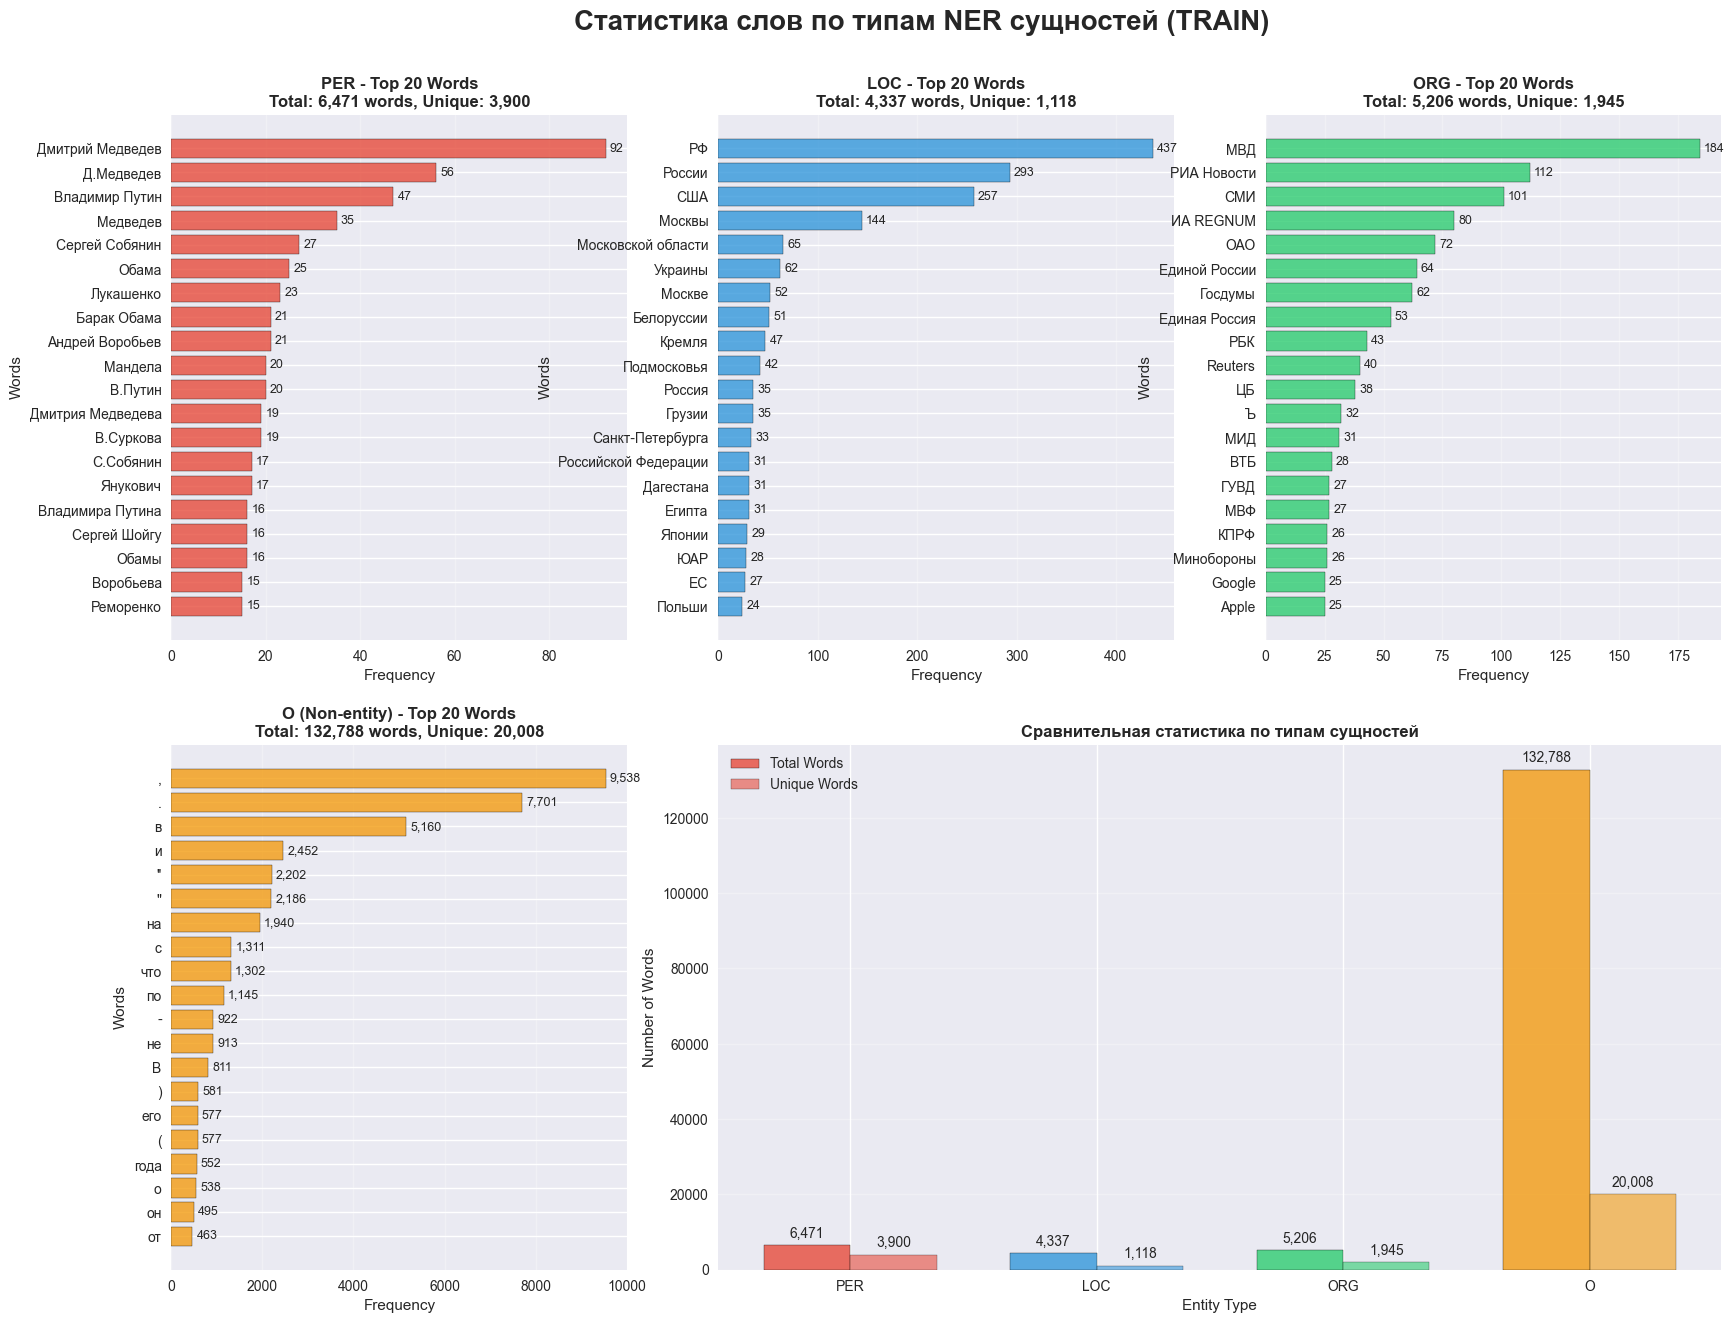

ДЕТАЛЬНАЯ СТАТИСТИКА СЛОВ ПО ТИПАМ NER СУЩНОСТЕЙ

PER:
  Всего слов: 6,471
  Уникальных слов: 3,900
  Коэффициент уникальности: 0.603
  Топ-5 слов: Дмитрий Медведев, Д.Медведев, Владимир Путин, Медведев, Сергей Собянин

LOC:
  Всего слов: 4,337
  Уникальных слов: 1,118
  Коэффициент уникальности: 0.258
  Топ-5 слов: РФ, России, США, Москвы, Московской области

ORG:
  Всего слов: 5,206
  Уникальных слов: 1,945
  Коэффициент уникальности: 0.374
  Топ-5 слов: МВД, РИА Новости, СМИ, ИА REGNUM, ОАО

O:
  Всего слов: 132,788
  Уникальных слов: 20,008
  Коэффициент уникальности: 0.151
  Топ-5 слов: ,, ., в, и, ''


In [74]:
plot_ner_word_statistics(entity_counts['train'])

### YARGY

#### Exp1. Набор самый "банальных" базовых правил

In [75]:
tokenizer = MorphTokenizer()

Name = fact('Name', ['first', 'last'])

FIRST_NAME = gram('Name').interpretation(Name.first)
LAST_NAME = gram('Surn').interpretation(Name.last)


PER_RULE = or_(
    rule(FIRST_NAME, LAST_NAME),
    rule(LAST_NAME, FIRST_NAME)
).interpretation(Name)


COUNTRIES = ['Россия', 'РФ', 'США', 'Украина', 'Германия', 'Франция', 'Китай']
CITIES = ['Москва', 'Петербург', 'Киев', 'Нью-Йорк', 'Лондон', 'Париж']

LOC_RULE = or_(
    rule(morph_pipeline(COUNTRIES)),
    rule(morph_pipeline(CITIES)),
    rule(gram('Geox'))  # географические названия
)


ORGANIZATIONS = [
    'ЛДПР', 'Государственная дума', 'компания', 'корпорация', 
    'фонд', 'университет', 'институт', 'завод', 'банк'
]

ORG_RULE = or_(
    rule(morph_pipeline(ORGANIZATIONS)),
    rule(gram('Orgn'))  # организации
)

per_parser = Parser(PER_RULE, tokenizer=tokenizer)
loc_parser = Parser(LOC_RULE, tokenizer=tokenizer)
org_parser = Parser(ORG_RULE, tokenizer=tokenizer)


In [76]:
def run_evaluation(
    data: List[Dict], 
    per_parser: Parser, 
    loc_parser: Parser, 
    org_parser: Parser
) -> List[Dict]:

    results = []
    
    for item in data:
        text = item['text']
        true_entities = item['entities']
        
        predicted_entities = extract_entities_yargy(text, per_parser, loc_parser, org_parser)
        
        results.append({
            'id': item['id'],
            'text': text,
            'true_entities': true_entities,
            'predicted_entities': predicted_entities
        })
    
    return results

In [77]:
natasha_data = load_natasha_data()
results = run_evaluation(
    natasha_data['test'],
    per_parser=per_parser,
    loc_parser=loc_parser,
    org_parser=org_parser
)
evaluate(results)

Общие метрики:
  Precision: 0.693
  Recall:    0.447
  F1:        0.543
  True entities: 5486
  Predicted entities: 3537
  Matches: 2451

Детализация по типам:
  PER:
    Precision: 0.954
    Recall:    0.374
    F1:        0.537
    True: 2187, Predicted: 856, Matches: 817
  LOC:
    Precision: 0.620
    Recall:    0.715
    F1:        0.664
    True: 1509, Predicted: 1741, Matches: 1079
  ORG:
    Precision: 0.590
    Recall:    0.310
    F1:        0.407
    True: 1790, Predicted: 940, Matches: 555


In [78]:
show_top_errors(results);


FN_LOC:
  Московской области: 24
  Кремля: 22
  Российской Федерации: 16
  Санкт-Петербурга: 12
  Тверской области: 6

FN_ORG:
  РИА Новости: 39
  ОАО: 32
  Единой России: 26
  СМИ: 26
  ИА REGNUM: 22

FN_PER:
  Д.Медведев: 34
  Обамы: 13
  Матвиенко: 10
  Д.Медведева: 8
  С.Собянин: 8

FP_LOC:
  того: 75
  России: 44
  Россия: 28
  мая: 20
  мае: 13

FP_ORG:
  компании: 59
  РИА: 40
  банка: 24
  компаний: 17
  компанию: 13

FP_PER:
  по Северо: 3
  В московском: 1
  Баффета Энди: 1
  А Минская: 1
  Ли Чжон: 1

TYPE_LOC_as_ORG:
  ЕС: 7

TYPE_ORG_as_LOC:
  Сколково: 7
  ФСЭГ: 5
  СНГ: 4
  Подмосковье: 2
  ОНЭКСИМа: 2

TYPE_PER_as_LOC:
  Мурси: 4
  Руснока: 4
  Близнюк: 2
  Назарова: 2
  Волосов: 2

TYPE_PER_as_ORG:
  Бартц: 1
  Сешнс: 1
  Спаритис: 1


Preparing NER analysis data...
Generating plots...

=== NER PERFORMANCE SUMMARY ===
Total entities: 5486
Correct predictions: 2451
Accuracy: 0.447
Missed entities: 2956
False positives: 1007
Type errors: 79


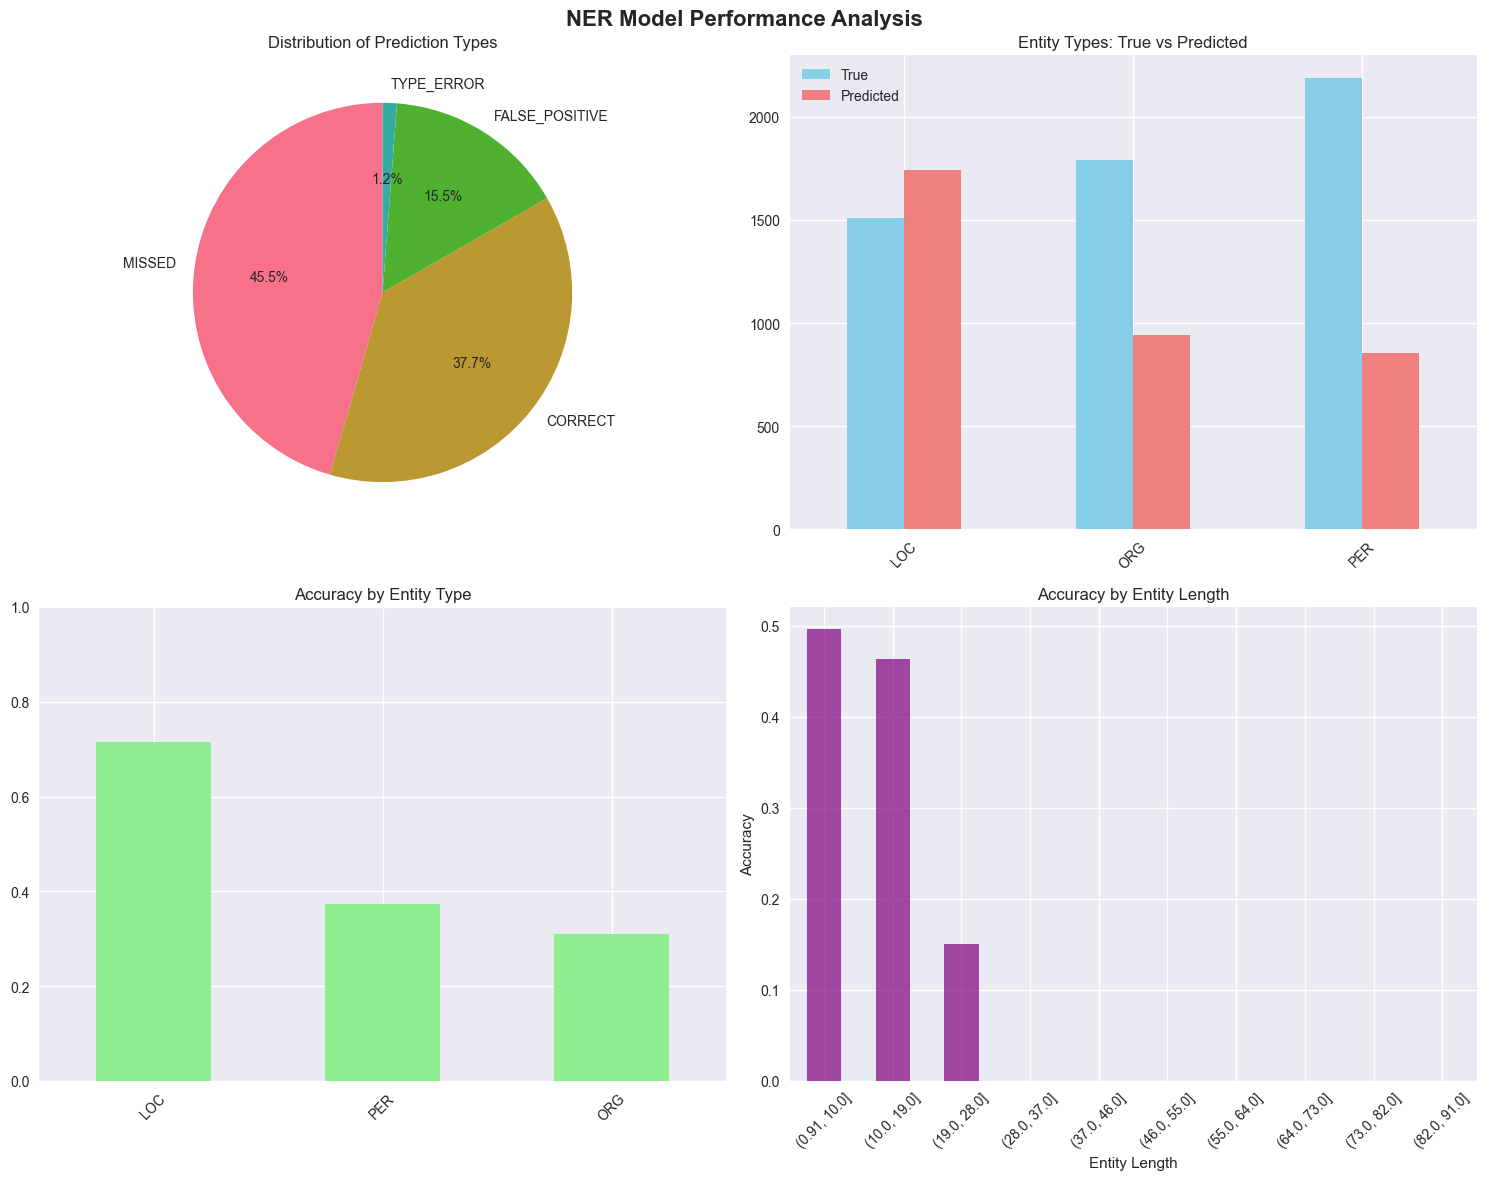

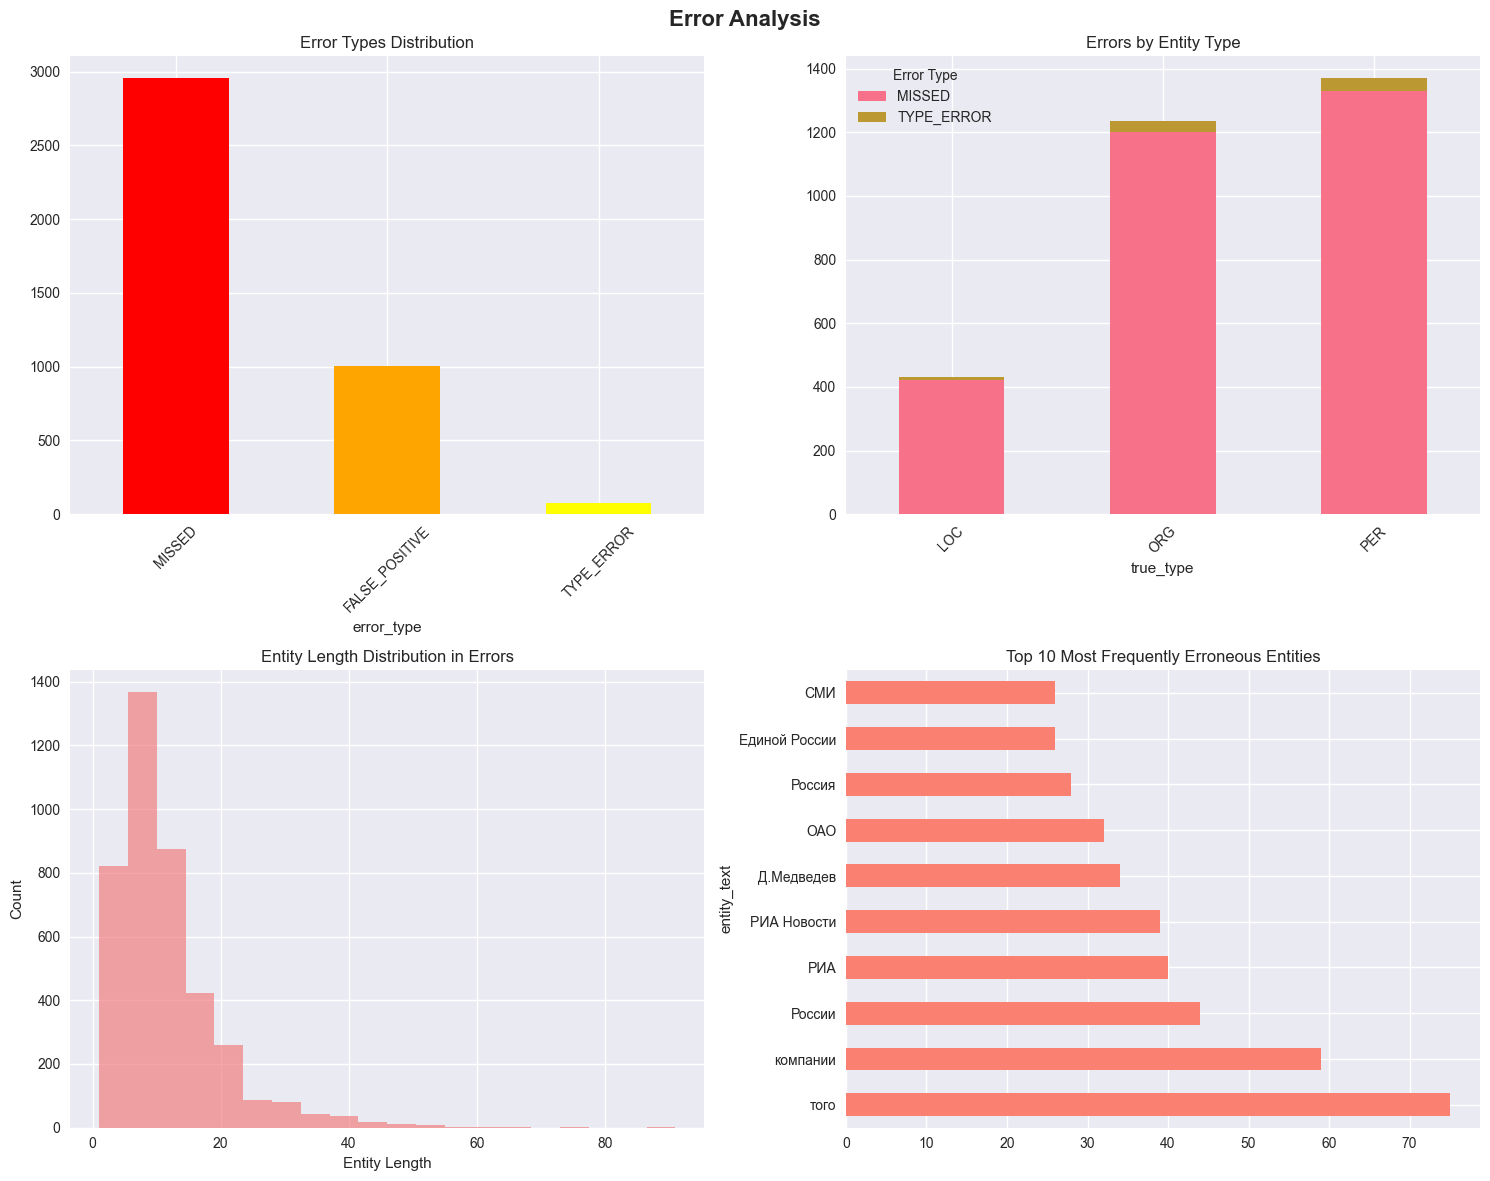

In [79]:
plots, analysis_df, error_df = generate_ner_report(results)

### Видно что минимальный набор правил Yarge ошибается в каждой категории и почти ничего не определяет. Улучшим результат кастомными правилами

#### Exp2. Новые правила на основе error analysis

In [80]:
tokenizer = MorphTokenizer()

# добавил инициалы 
PER_RULE = or_(PER_ABBREVIATED, FINAL_PER_RULE).interpretation(Name)

COUNTRIES = ['Россия', 'РФ', 'США', 'Украина', 'Германия', 'Франция', 'Китай']
CITIES = ['Москва', 'Петербург', 'Киев', 'Нью-Йорк', 'Лондон', 'Париж']

# vvvvvvvvvvvvvvvvv
LOCATIONS = [
    'Московская область',
    'Кремль',
    'Российская Федерация',
    'Санкт-Петербург',
    'Тверская область',
    'Свердловская область',
    'Красноярский крй',
    'Брянская область',
    'Белый дом',
    'Ленинградская область'
]
# ^^^^^^^^^^^^^^^^^

LOC_RULE = or_(
    rule(morph_pipeline(COUNTRIES)),
    rule(morph_pipeline(CITIES)),
    rule(morph_pipeline(LOCATIONS)),
    rule(gram('Geox'))  # географические названия
)


ORGANIZATIONS = [
    'ЛДПР', 'Государственная дума', 'корпорация', 
    'фонд', 'университет', 'институт', 'завод',

    # vvvvvvvvvvvvvv
    'компан', # ия/ии
    'ООО', 'ОАО', 'МВД', 'СМИ',
    'РИА Новости', 'РИА', 'Ъ',
    'Справедливая Россия', 'Единая Россия',


    'Единой России',
    'ИА REGNUM',
    'Единая Россия',
    'Apple',
    'Следственный комитет',
    # ^^^^^^^^^^^^^^
]
ORG_RULE = or_(
    rule(morph_pipeline(ORGANIZATIONS)),
    rule(gram('Orgn'))
)

per_parser = Parser(PER_RULE, tokenizer=tokenizer) # вот тут правило из дипсика
loc_parser = Parser(LOC_RULE, tokenizer=tokenizer)
org_parser = Parser(ORG_RULE, tokenizer=tokenizer)


In [81]:
natasha_data = load_natasha_data()
results = run_evaluation(
    natasha_data['test'],
    per_parser=per_parser,
    loc_parser=loc_parser,
    org_parser=org_parser
)


def filter_togo(x):
    return not(('того' in x['text']) or ('итого' in x['text']))


for i, res in enumerate(results):
    results[i]['predicted_entities'] = list(filter(filter_togo, res['predicted_entities']))

evaluate(results)

Общие метрики:
  Precision: 0.795
  Recall:    0.552
  F1:        0.652
  True entities: 5486
  Predicted entities: 3807
  Matches: 3028

Детализация по типам:
  PER:
    Precision: 0.955
    Recall:    0.509
    F1:        0.664
    True: 2187, Predicted: 1165, Matches: 1113
  LOC:
    Precision: 0.692
    Recall:    0.795
    F1:        0.740
    True: 1509, Predicted: 1732, Matches: 1199
  ORG:
    Precision: 0.787
    Recall:    0.400
    F1:        0.530
    True: 1790, Predicted: 910, Matches: 716


In [82]:
show_top_errors(results);


FN_LOC:
  Красноярского края: 6
  Ярославской области: 5
  Самарской области: 4
  Мурманской области: 4
  Карачаево-Черкесии: 4

FN_ORG:
  Единой России: 26
  Единая Россия: 19
  Совета Федерации: 9
  ГУ: 9
  ЕР: 7

FN_PER:
  Обамы: 13
  Матвиенко: 10
  Полтавченко: 7
  Реморенко: 7
  Обама: 7

FP_LOC:
  России: 44
  Россия: 28
  мая: 20
  мае: 13
  котором: 13

FP_ORG:
  фонда: 11
  института: 10
  корпорации: 9
  институт: 8
  завода: 5

FP_PER:
  О том: 4
  по Северо: 3
  В марте: 3
  В московском: 1
  Баффета Энди: 1

TYPE_LOC_as_ORG:
  ЕС: 7

TYPE_ORG_as_LOC:
  Сколково: 7
  ФСЭГ: 5
  СНГ: 4
  Подмосковье: 2
  ОНЭКСИМа: 2

TYPE_PER_as_LOC:
  Мурси: 4
  Руснока: 4
  Близнюк: 2
  Назарова: 2
  Волосов: 2

TYPE_PER_as_ORG:
  Бартц: 1
  Сешнс: 1
  Спаритис: 1


Preparing NER analysis data...
Generating plots...

=== NER PERFORMANCE SUMMARY ===
Total entities: 5486
Correct predictions: 3028
Accuracy: 0.552
Missed entities: 2375
False positives: 696
Type errors: 83


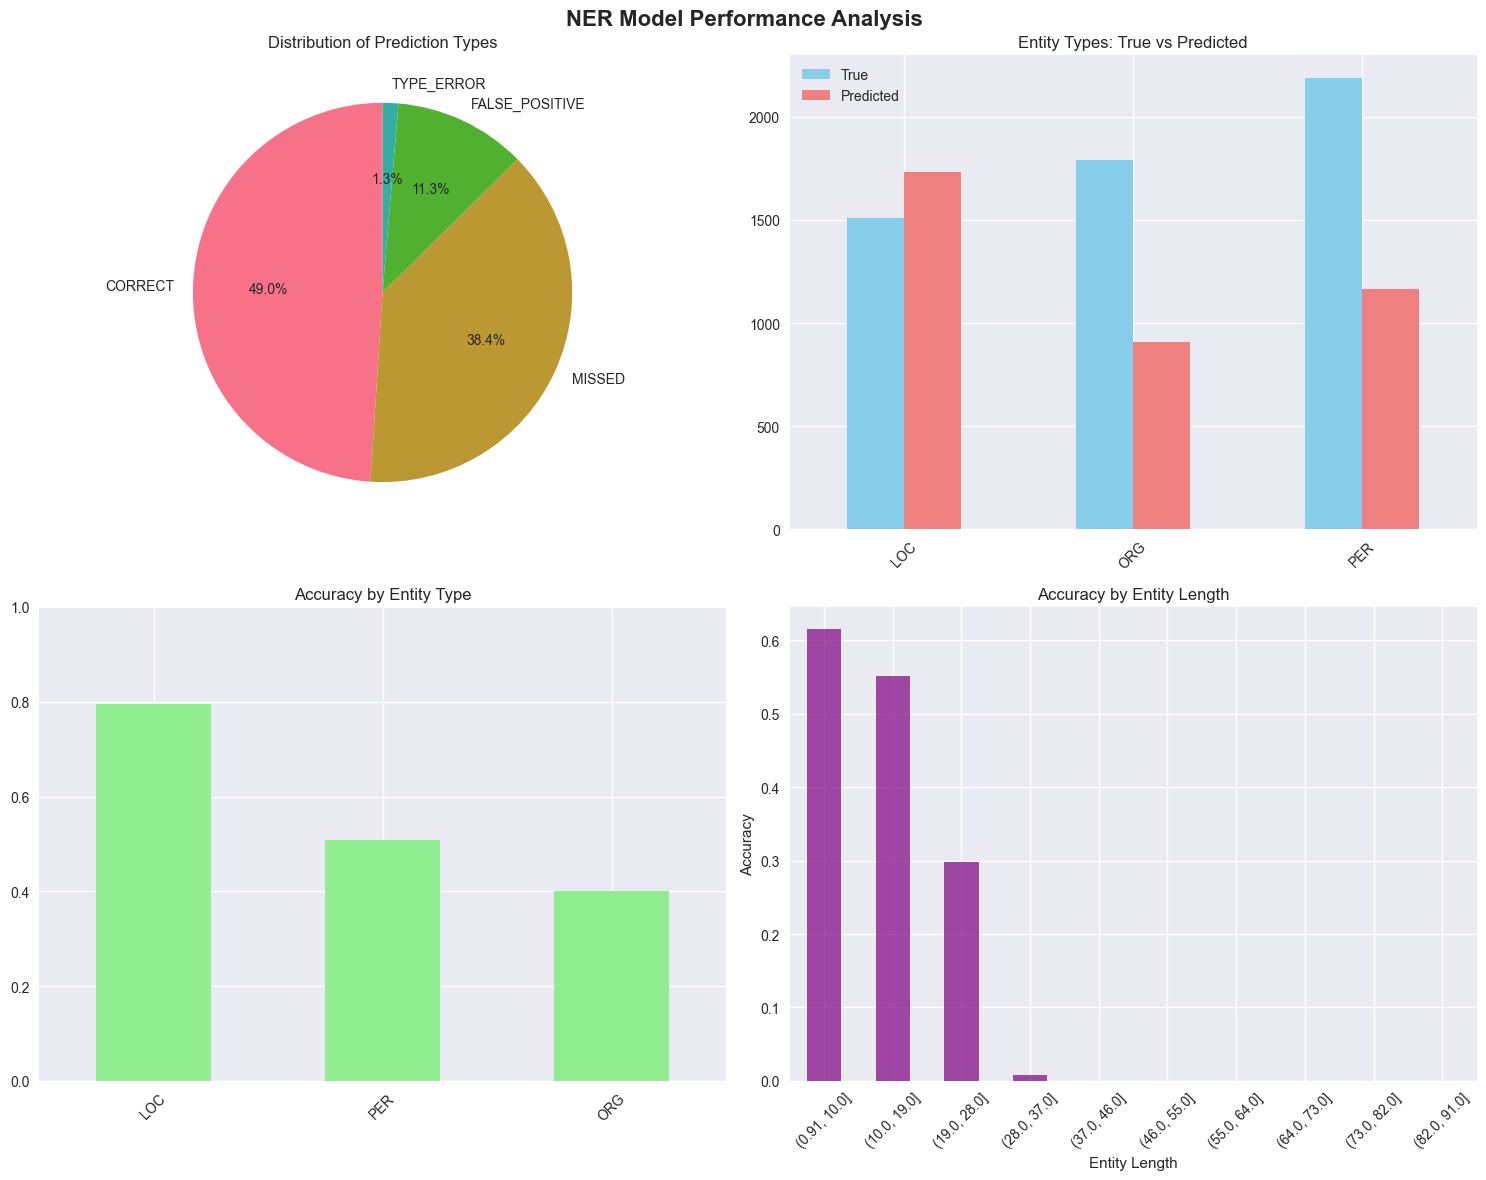

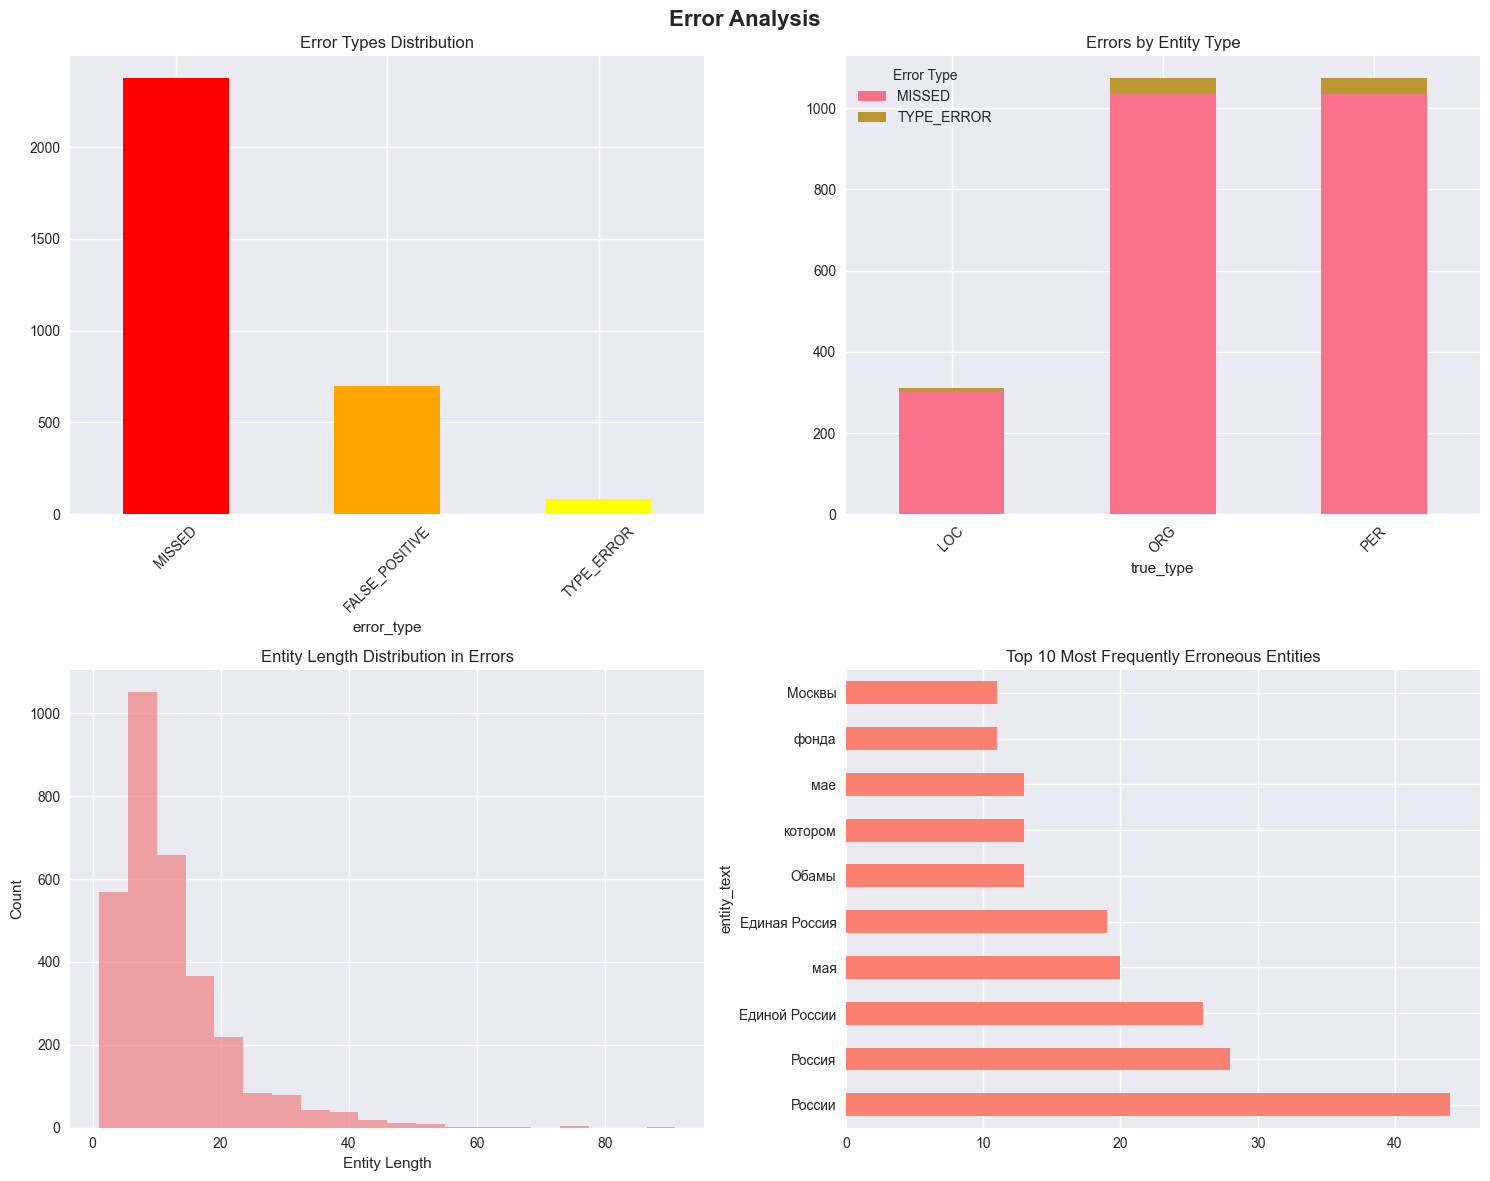

In [83]:
plots, analysis_df, error_df = generate_ner_report(results)

### После кастомных правил стало намного лучше.

добавили 
1) кучу имен и фамилий (сгенерили дипсиком)
2) инициацы (по еррор анализу поняли что в датасете много имен через инициалы)

3) также по еррор анализу накидали список локаций и организаций 
4) осталось много проблем с тем что `Россия` оказывается в False Positive из за того что есть оранизация `Единая Россия` и локация `Россия`.

### NATASHA
#### Наташа взята как более продвинутый rule-based подход

In [84]:
class NatashaPipeline:
    def __init__(self):

        self.segmenter = Segmenter()
        self.morph_vocab = MorphVocab()
        
        self.emb = NewsEmbedding()
        self.morph_tagger = NewsMorphTagger(self.emb)
        self.syntax_parser = NewsSyntaxParser(self.emb) 
        self.ner_tagger = NewsNERTagger(self.emb)
    
    
    def process_text(self, text: str) -> Doc:
       
        doc = Doc(text)
        
        doc.segment(self.segmenter)
        doc.tag_morph(self.morph_tagger)
        doc.parse_syntax(self.syntax_parser) 
        doc.tag_ner(self.ner_tagger)
        
        for span in doc.spans:
            span.normalize(self.morph_vocab)
            
        return doc
    
    
    def extract_entities(self, doc: Doc) -> List[Dict[str, Any]]:
        
        entities = []
        
        for span in doc.spans:
            if span.type in ['PER', 'LOC', 'ORG']:
                entity = {
                    'text': span.text,
                    'type': span.type,
                    'start': span.start,
                    'end': span.stop,
                    'normalized': span.normal
                }
                entities.append(entity)
        
        return entities
    
    
    def inference(self, natasha_data: List) -> List:

        results = []
        
        for _, example in enumerate(natasha_data):
            
            text = example['text']
            true_entities = example['entities']            

            doc = self.process_text(text)
            predicted_entities = self.extract_entities(doc)

            results.append({
                'text': text,
                'true_entities': true_entities,
                'predicted_entities': predicted_entities,
                'id': example['id']
            })
        
        return results

In [85]:
natasha_data = load_natasha_data()

pipeline = NatashaPipeline()

### Test on one sample

In [86]:
test_example = natasha_data['validation'][0]
doc = pipeline.process_text(test_example['text'])
entities = pipeline.extract_entities(doc)

print(f"Текст: {test_example['text'][:100]}...")
print("\nИстинные сущности:")
for ent in test_example['entities']:
    print(f"  {ent['type']}: '{ent['text']}'")

print("\nНайденные Natasha сущности:")
for ent in entities:
    print(f"  {ent['type']}: '{ent['text']}' (нормализовано: '{ent['normalized']}')")

Текст: как акционерный коммерческий Московский муниципальный банк - Банк Москвы ,контрольный пакет акций ко...

Истинные сущности:
  ORG: 'Московский муниципальный банк - Банк Москвы'
  LOC: 'Москвы'

Найденные Natasha сущности:
  ORG: 'Московский муниципальный банк' (нормализовано: 'Московский муниципальный банк')
  ORG: 'Банк Москвы' (нормализовано: 'Банк Москвы')
  LOC: 'Москвы' (нормализовано: 'Москва')


### EXP1: Baseline Natasha

In [87]:
results = pipeline.inference(natasha_data['test'])

In [88]:
evaluate(results)

Общие метрики:
  Precision: 0.919
  Recall:    0.874
  F1:        0.896
  True entities: 5486
  Predicted entities: 5217
  Matches: 4795

Детализация по типам:
  PER:
    Precision: 0.958
    Recall:    0.900
    F1:        0.928
    True: 2187, Predicted: 2056, Matches: 1969
  LOC:
    Precision: 0.958
    Recall:    0.976
    F1:        0.967
    True: 1509, Predicted: 1538, Matches: 1473
  ORG:
    Precision: 0.834
    Recall:    0.756
    F1:        0.793
    True: 1790, Predicted: 1623, Matches: 1353


In [89]:
show_top_errors(results);


FN_LOC:
  России: 1
  Хурал: 1
  Кот-д'Ивуара: 1
  г.Смоленске: 1
  Северо-Кавказском федеральном округе: 1

FN_ORG:
  ОАО: 32
  ООО: 14
  Единой России: 13
  Ъ: 13
  Коммерсантъ: 10

FN_PER:
  Д.Медведев: 24
  Обама: 5
  С.Собянин: 3
  Реморенко: 3
  М.Прохоров: 2

FP_LOC:
  России: 17
  РФ: 2
  Российской Федерации: 2
  Россией: 2
  СССР: 2

FP_ORG:
  I-ORG: 15
  I-PER: 10
  33-й ракетной армией: 4
  ГФИ: 3
  B-ORG: 3

FP_PER:
  I-PER: 2
  Символичным: 1
  Карли Фиорину( Carly Fiorina ): 1
  Андрис Америкс( ЧСР ): 1
  Брюсом Клафлином( Bruce Claflin ): 1

TYPE_LOC_as_ORG:
  Сколково: 1
  МСФО: 1
  МОСКВА: 1
  ЗАТО: 1
  ПЕРМЬ: 1

TYPE_LOC_as_PER:
  Теланганы: 3
  Дерсим: 1
  Муром: 1
  Калифорни: 1
  Ставрополем: 1

TYPE_ORG_as_LOC:
  Евросоюз: 1
  Белого дома: 1
  Белый дом: 1
  Новодевичьему монастырю: 1
  Кремля: 1

TYPE_ORG_as_PER:
  Главмосинжстрой: 1
  Главмоспромстрой: 1
  Росинформтехнологии: 1
  Интерросом: 1
  Алтай-Кокса: 1

TYPE_PER_as_LOC:
  Собянин: 1
  Руснока: 1
  Гам

Preparing NER analysis data...
Generating plots...

=== NER PERFORMANCE SUMMARY ===
Total entities: 5486
Correct predictions: 4795
Accuracy: 0.874
Missed entities: 656
False positives: 387
Type errors: 35


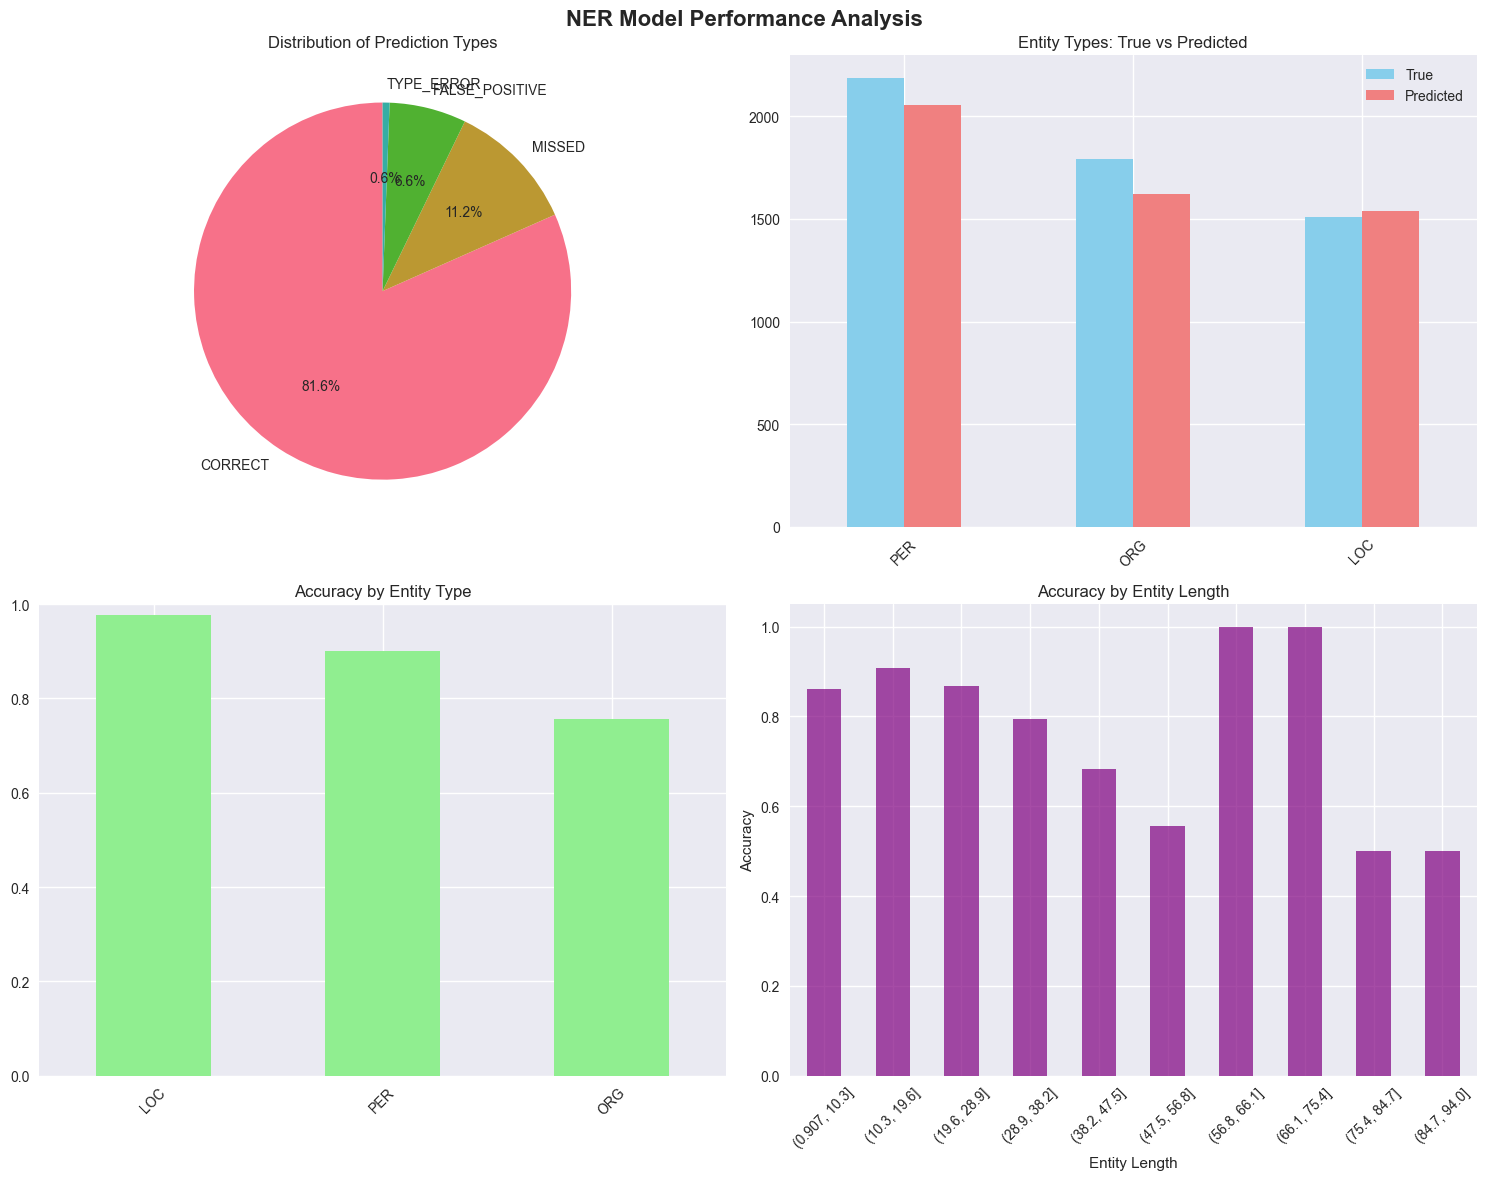

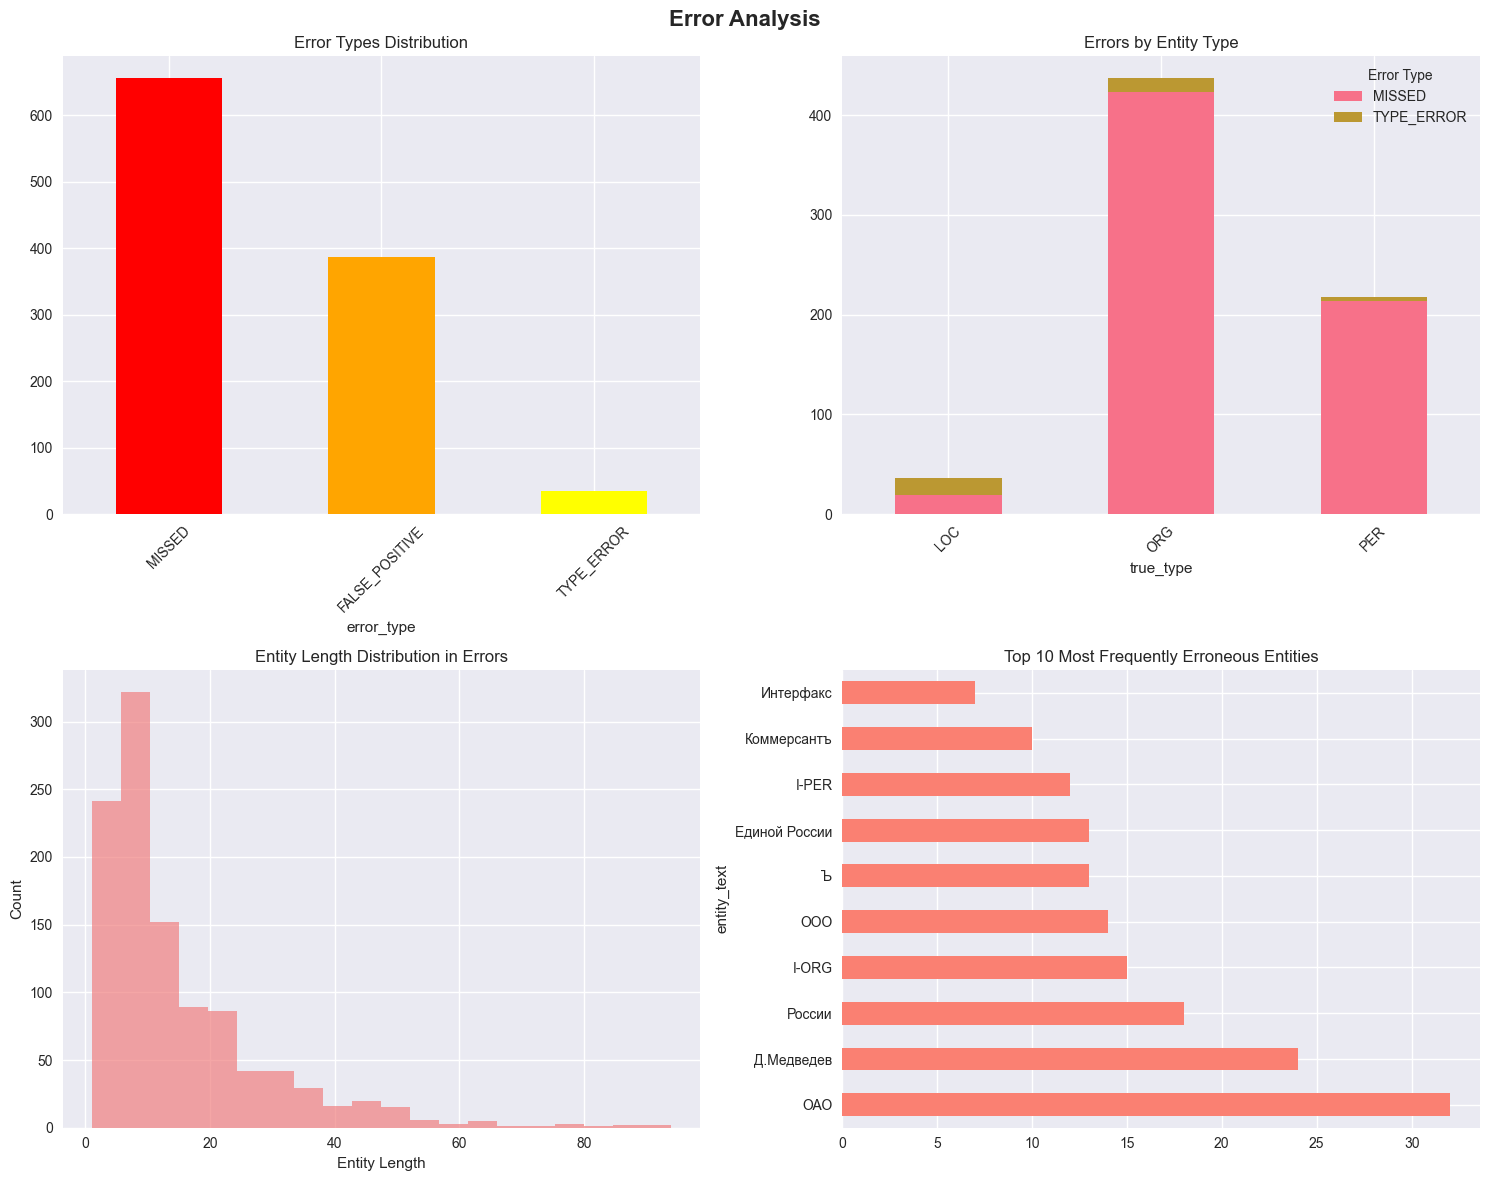

In [90]:
plots, analysis_df, error_df = generate_ner_report(results)

### Наташа из коробки является отличным бейзлайном. Ошибается в именах с иницалами и в локальных организациях. Данный бейзлайн решили не улучшать